In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

In [25]:
dfs = []
for param in ["beta", "n"]:
    for boot in [True, False]:
        tmp_df = pd.read_csv(f"inverted_double_pendulum_{'b' if boot else 'nb'}_{param}.csv")
        tmp_df["param_name"] = param
        tmp_df["bootstrapping"] = boot
        dfs.append(tmp_df)
df = pd.concat(dfs, ignore_index=True)
df = df.fillna(0)
df

,param,i_0,i_1,i_2,i_3,i_4,i_5,i_6,i_7,i_8,...,i_42,i_43,i_44,i_45,i_46,i_47,i_48,i_49,param_name,bootstrapping
0,1.000000,9358.116211,9358.263672,9358.056641,9357.934570,9358.047852,9358.040039,9358.065430,9358.175781,9358.100586,...,9358.050781,9358.085938,0.000000,9358.186523,9358.151367,9358.048828,9358.004883,9357.987305,beta,True
1,0.900000,9358.484375,9358.311523,9358.306641,9358.385742,9358.424805,9358.393555,9358.315430,9358.592773,9358.331055,...,9358.710938,9358.541016,0.000000,9358.523438,9358.574219,9358.670898,9358.399414,9358.479492,beta,True
2,0.800000,9358.590820,9358.436523,9358.518555,9358.551758,9358.540039,9358.494141,9358.475586,9358.848633,9358.447266,...,9358.872070,9358.736328,0.000000,9358.725586,9359.080078,9359.015625,9358.881836,9358.979492,beta,True
3,0.700000,9358.596680,9358.611328,9358.717773,9358.619141,9358.653320,9358.624023,9358.655273,9359.094727,9358.627930,...,9358.983398,9359.472656,0.000000,9358.926758,9358.862305,9359.122070,9358.859375,9359.005859,beta,True
4,0.600000,9358.745117,9358.902344,9358.872070,9358.823242,9358.856445,9358.931641,9358.948242,9359.264648,9358.842773,...,9359.565430,9359.570312,0.000000,9359.693359,9359.654297,9359.748047,9359.440430,9359.718750,beta,True
5,0.500000,9358.861328,9359.010742,9359.027344,9359.006836,9359.002930,9359.067383,9359.025391,9359.687500,9359.002930,...,9359.768555,9359.788086,0.000000,5146.825684,5011.784180,3447.409424,9359.751953,9359.498047,beta,True
6,0.400000,8454.219727,9359.161133,9359.077148,9359.106445,9359.084961,9359.213867,9359.122070,4648.116699,9359.025391,...,4439.431152,4226.416504,0.000000,2644.558350,2642.794189,1536.106812,666.350830,8173.673340,beta,True
7,0.300000,1660.405884,3422.522217,4460.721191,5517.201660,3030.841797,4055.511719,1142.160034,2797.750732,2673.542236,...,340.716919,1434.807495,0.000000,581.604126,1140.885132,220.889359,316.533844,3244.860840,beta,True
8,0.200000,975.548645,1218.851929,1199.961914,1244.906494,1072.744995,808.957336,2487.112061,758.316650,1090.827393,...,153.835800,255.185822,0.000000,185.279251,456.788147,164.564407,207.737900,2515.693115,beta,True
9,0.100000,810.865417,736.030762,706.239380,795.862366,717.371338,756.645447,812.978699,268.139282,734.376892,...,120.226051,194.873520,0.000000,129.558380,218.922714,140.507568,183.419220,479.779449,beta,True


In [26]:
# i_cols = [c for c in df.columns if c.startswith("i_")]
# heatmap_df = tmp_df.set_index("param")[i_cols]
# plt.figure(figsize=(15, 5))
# sns.heatmap(
#     heatmap_df,
#     cmap="viridis",
#     cbar=True,
#     norm=LogNorm(),
# )
# plt.xlabel("i")
# plt.ylabel("param")
# plt.title("Parameter Heatmap")
# plt.show()

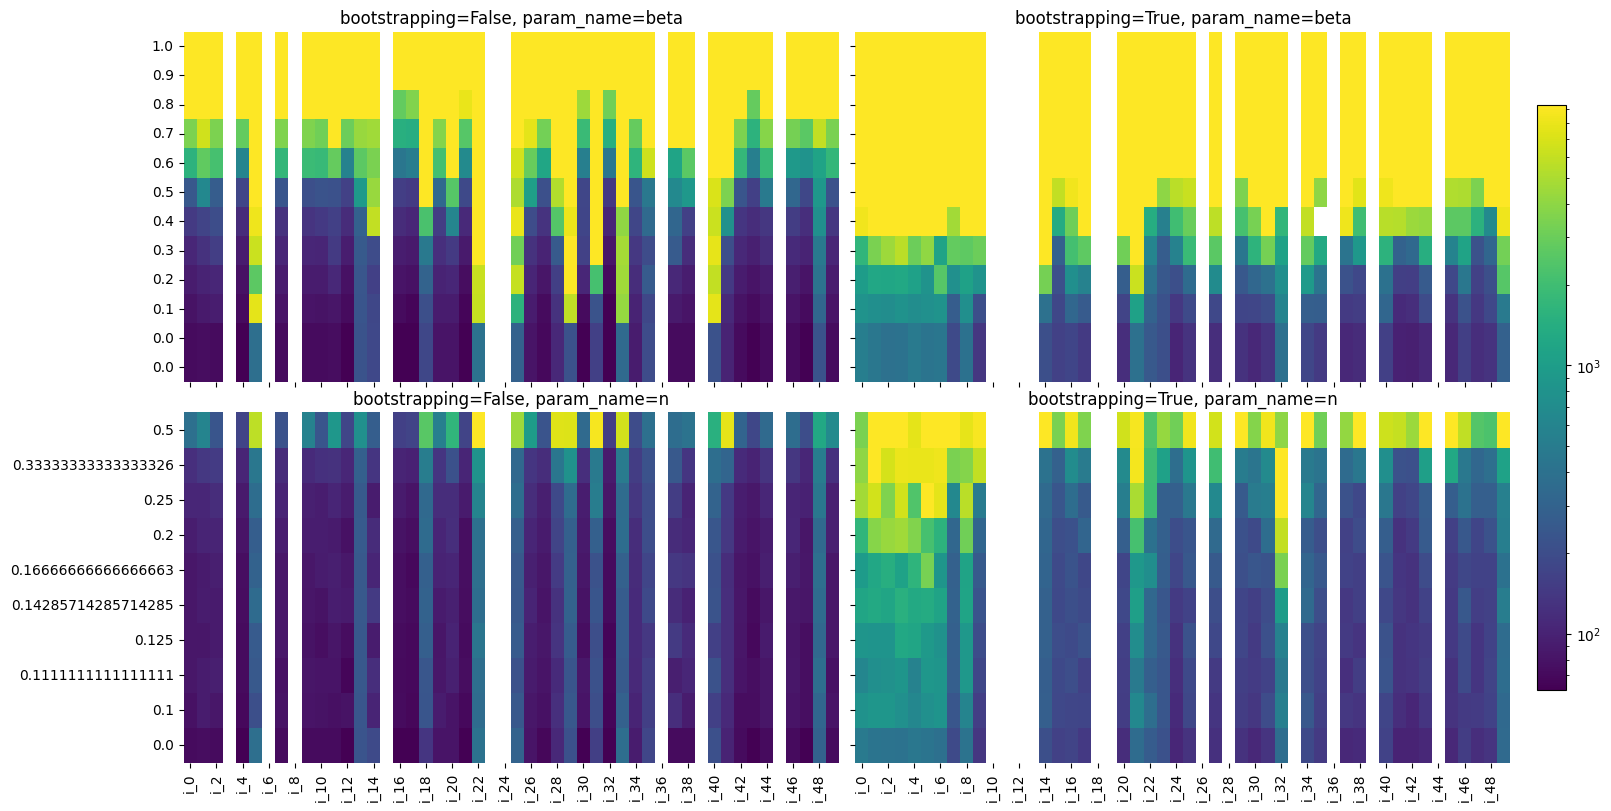

In [32]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    sharex=True,
    sharey="row",
    constrained_layout=True
)

# shared normalization
all_values = df[i_cols].values
norm = LogNorm(
    vmin=all_values[all_values > 0].min(),
    vmax=all_values.max()
)

mappable = None

for col, boot in enumerate([False, True]):
    for row, pname in enumerate(["beta", "n"]):

        ax = axes[row, col]

        subset = df[
            (df["bootstrapping"] == boot) &
            (df["param_name"] == pname)
        ]

        heatmap_df = subset.set_index("param")[i_cols]

        hm = sns.heatmap(
            heatmap_df,
            cmap="viridis",
            norm=norm,
            cbar=False,   # no individual colorbars
            ax=ax
        )
        ax.tick_params(axis="y", labelrotation=0)

        if mappable is None:
            mappable = hm.collections[0]

        ax.set_title(f"bootstrapping={boot}, param_name={pname}")
        ax.set_xlabel("")
        ax.set_ylabel("")

# add one colorbar aligned with the whole grid
fig.colorbar(
    mappable,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.02
)

plt.show()

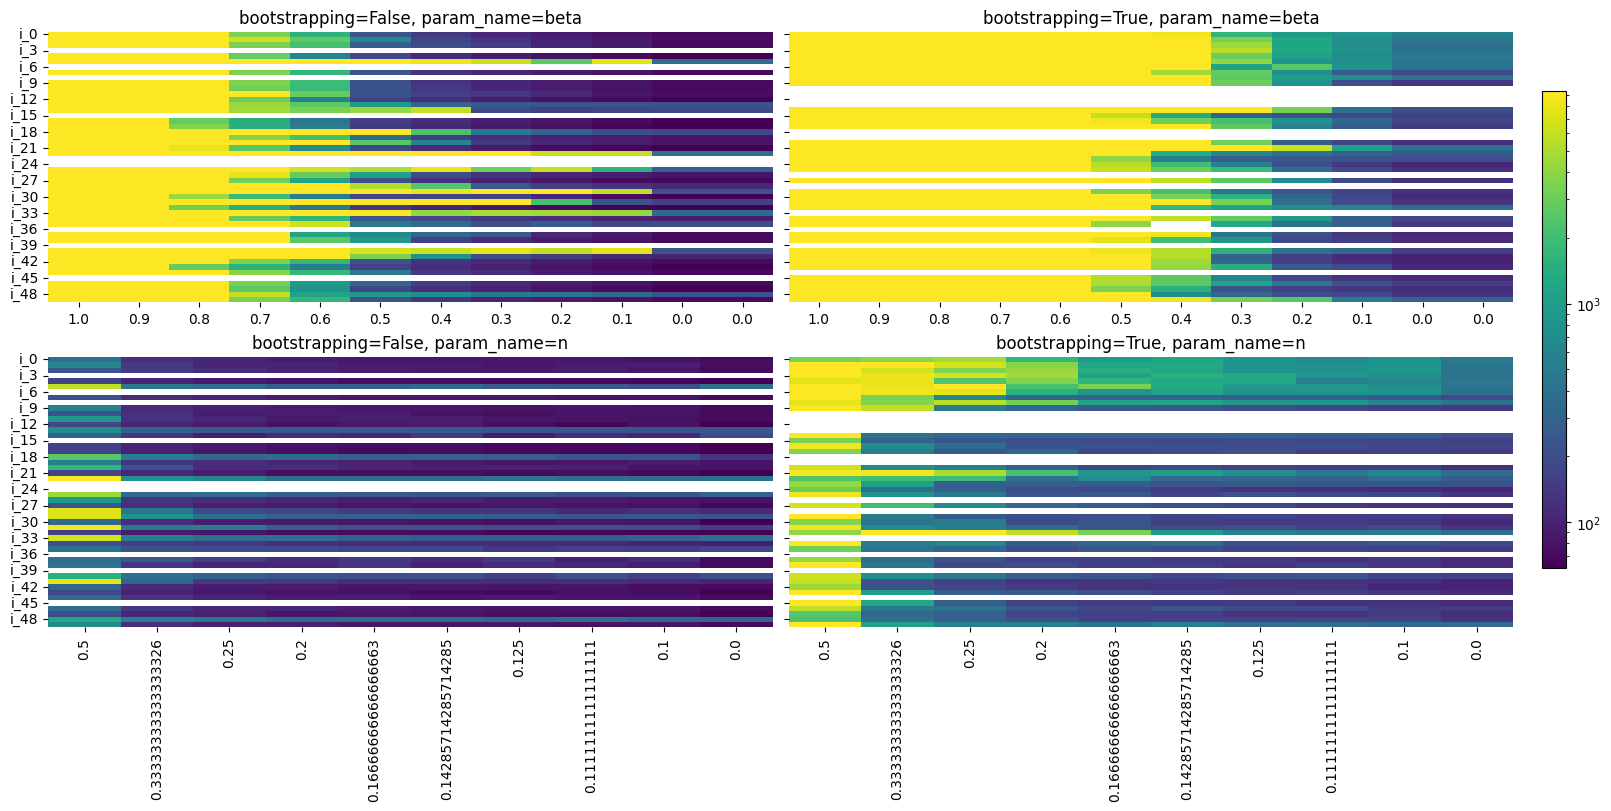

In [35]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    sharex="row",
    sharey=True,
    constrained_layout=True
)

# shared normalization
all_values = df[i_cols].values
norm = LogNorm(
    vmin=all_values[all_values > 0].min(),
    vmax=all_values.max()
)

mappable = None

for col, boot in enumerate([False, True]):
    for row, pname in enumerate(["beta", "n"]):

        ax = axes[row, col]

        subset = df[
            (df["bootstrapping"] == boot) &
            (df["param_name"] == pname)
        ]

        heatmap_df = subset.set_index("param")[i_cols].T

        hm = sns.heatmap(
            heatmap_df,
            cmap="viridis",
            norm=norm,
            cbar=False,   # no individual colorbars
            ax=ax
        )
        ax.tick_params(axis="y", labelrotation=0)

        if mappable is None:
            mappable = hm.collections[0]

        ax.set_title(f"bootstrapping={boot}, param_name={pname}")
        ax.set_xlabel("")
        ax.set_ylabel("")

# add one colorbar aligned with the whole grid
fig.colorbar(
    mappable,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.02
)

plt.show()

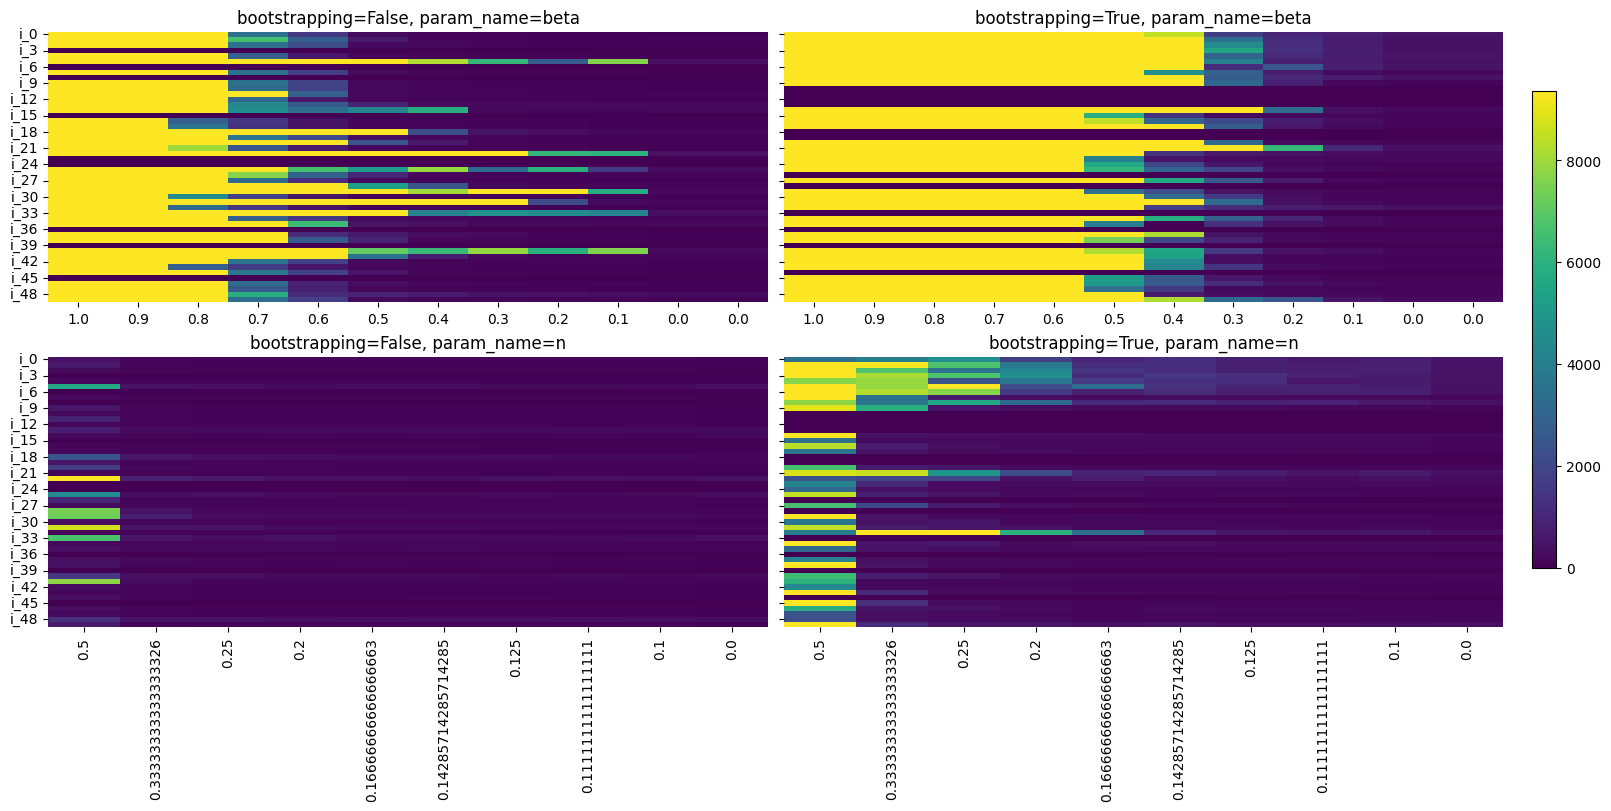

In [36]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 8),
    sharex="row",
    sharey=True,
    constrained_layout=True
)

# shared normalization
all_values = df[i_cols].values
norm = Normalize(
    vmin=all_values.min(),
    vmax=all_values.max()
)

mappable = None

for col, boot in enumerate([False, True]):
    for row, pname in enumerate(["beta", "n"]):

        ax = axes[row, col]

        subset = df[
            (df["bootstrapping"] == boot) &
            (df["param_name"] == pname)
        ]

        heatmap_df = subset.set_index("param")[i_cols].T

        hm = sns.heatmap(
            heatmap_df,
            cmap="viridis",
            norm=norm,
            cbar=False,   # no individual colorbars
            ax=ax
        )
        ax.tick_params(axis="y", labelrotation=0)

        if mappable is None:
            mappable = hm.collections[0]

        ax.set_title(f"bootstrapping={boot}, param_name={pname}")
        ax.set_xlabel("")
        ax.set_ylabel("")

# add one colorbar aligned with the whole grid
fig.colorbar(
    mappable,
    ax=axes,
    location="right",
    shrink=0.8,
    pad=0.02
)

plt.show()